**Import Libraries**

In [1]:
import category_encoders as ce
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, max_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import warnings
import pickle
warnings.filterwarnings("ignore", category=FutureWarning)

**Load and Clean Dataset**

In [2]:
# Load the latest production master dataset
df = pd.read_csv("jeddah_air_cargo_occupancy_master.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# ADAPTIVE COUPLING LAYER: Reconstruct the legacy 'zone' category strictly for plotting/reporting
def map_to_legacy_zone(row):
    st, fd = row["storage_type"], row["flow_direction"]
    if st == "General" and fd == "Import": return "Import"
    if st == "General" and fd == "Export": return "Export"
    if st == "Cold Chain": return "Cold Chain"
    if st == "Dangerous Goods": return "DG"
    if st == "VIP": return "VIP"
    return "Import"

df["zone"] = df.apply(map_to_legacy_zone, axis=1)

# CRITICAL TIME-SERIES CONSTRAINT: Enforce strict chronological sorting
df = df.sort_values(by=["timestamp", "storage_type", "flow_direction"]).reset_index(drop=True)

print(f"Dataset successfully structured. Shape: {df.shape}")
print("Active Storage Types detected natively:", df["storage_type"].unique().tolist())

Dataset successfully structured. Shape: (43800, 22)
Active Storage Types detected natively: ['Cold Chain', 'Dangerous Goods', 'General', 'VIP']


**Data Visualization**

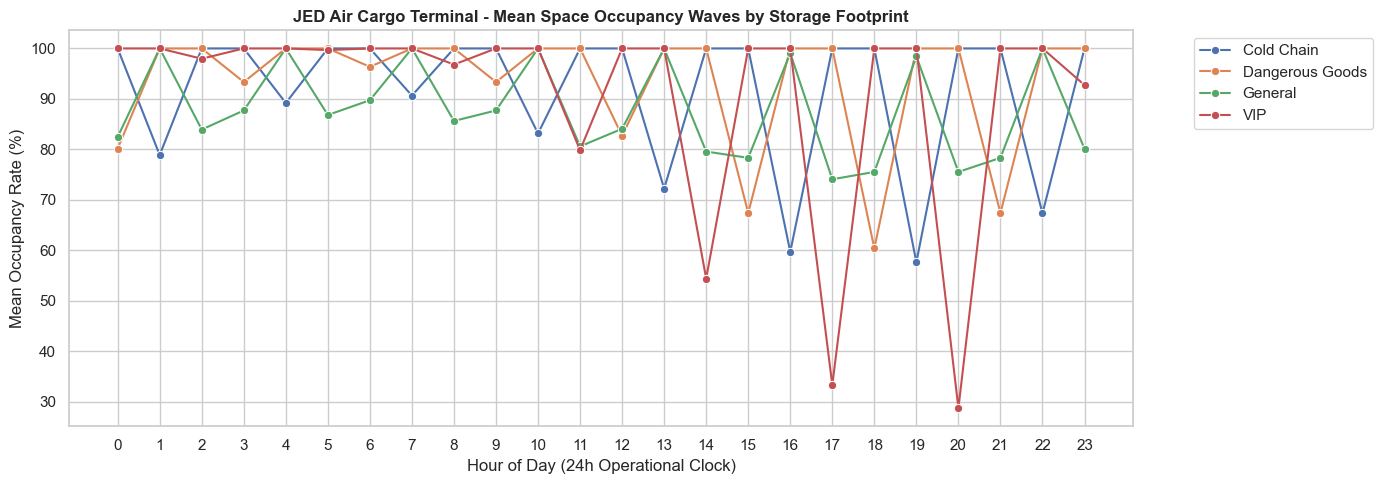

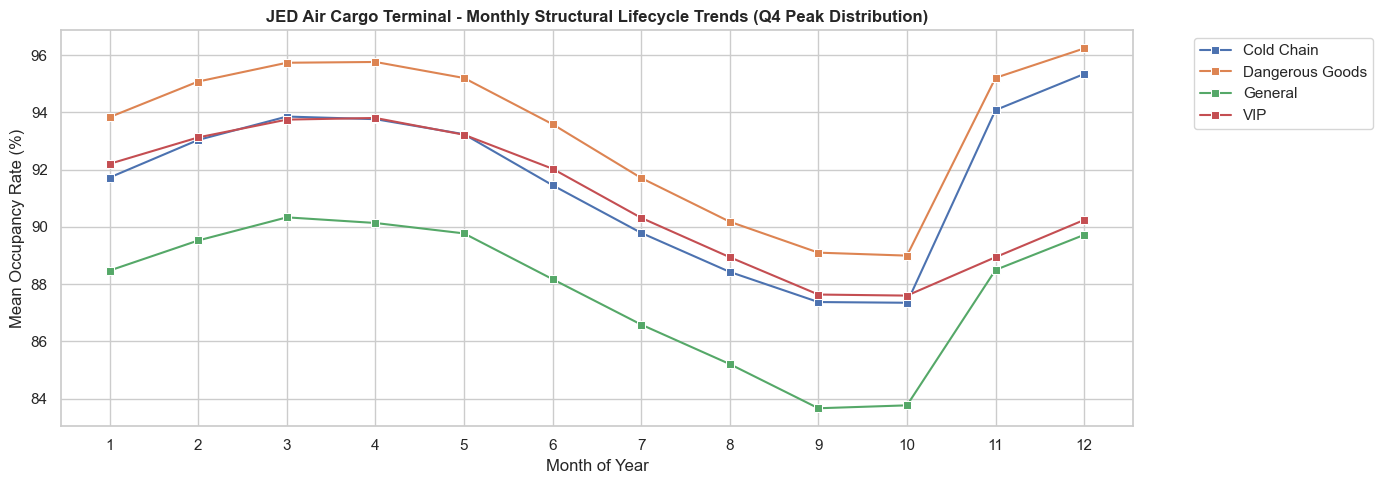

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Temporary columns generated exclusively for trend profiles
df["_hour"] = df["timestamp"].dt.hour
df["_month"] = df["timestamp"].dt.month

# Chart 1: Hourly Operational Wave Fluctuations
plt.figure()
sns.lineplot(data=df, x="_hour", y="occupancy_rate", hue="storage_type", marker="o", errorbar=None)
plt.title("JED Air Cargo Terminal - Mean Space Occupancy Waves by Storage Footprint", fontsize=12, fontweight='bold')
plt.xlabel("Hour of Day (24h Operational Clock)")
plt.ylabel("Mean Occupancy Rate (%)")
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("jeddah_hourly_waves.png", bbox_inches='tight')

# Chart 2: Monthly Structural Lifecycle Tracking (Revealing Q4 Peak Volume Surges)
plt.figure()
sns.lineplot(data=df, x="_month", y="occupancy_rate", hue="storage_type", marker="s", errorbar=None)
plt.title("JED Air Cargo Terminal - Monthly Structural Lifecycle Trends (Q4 Peak Distribution)", fontsize=12, fontweight='bold')
plt.xlabel("Month of Year")
plt.ylabel("Mean Occupancy Rate (%)")
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("jeddah_monthly_seasonality.png", bbox_inches='tight')

# Drop temporary logging columns to preserve data cleanliness
df = df.drop(columns=["_hour", "_month"])

**Data Feature Engineering**

In [4]:
# Derive calendar feature space anchors on the master chronological data
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month_of_year"] = df["timestamp"].dt.month

# Define structural matrix boundaries for leakage-free modeling
numerical_features = [
    "uld_count",
    "expected_flight_volume_kg",
    "hours_until_arrival",
    "hours_until_departure",
    "historical_dwell_lag_24h",
    "congestion_index",
    "forecasted_demand_next_24h",
    "forecasted_demand_next_48h",
    "forecasted_demand_next_72h",
    "hour_of_day",
    "day_of_week",
    "month_of_year",
]

# NATIVE FEATURES DEFINITION: Map the split direction and storage features directly
low_cardinality_categoricals = ["flow_direction", "storage_type", "iata_shc", "build_up_status"]
high_cardinality_categorical = ["route"]
target_variable = "occupancy_rate"

print(f" Feature engineering layout locked. Total continuous model inputs: {len(numerical_features) + len(low_cardinality_categoricals) + 1}")

 Feature engineering layout locked. Total continuous model inputs: 17


**Time-Series Cross-Validation Setup (Expanding Window)**

In [5]:
# Initialize a 5-fold expanding window cross-validation splitter
tscv = TimeSeriesSplit(n_splits=5)

print("Chronological Expanding Cross-Validation Segments Established:")
for fold, (train_index, val_index) in enumerate(tscv.split(df)):
    print(f"  • Fold {fold + 1}: Training History = {len(train_index)} rows | Forward Lookahead Validation = {len(val_index)} rows")

Chronological Expanding Cross-Validation Segments Established:
  • Fold 1: Training History = 7300 rows | Forward Lookahead Validation = 7300 rows
  • Fold 2: Training History = 14600 rows | Forward Lookahead Validation = 7300 rows
  • Fold 3: Training History = 21900 rows | Forward Lookahead Validation = 7300 rows
  • Fold 4: Training History = 29200 rows | Forward Lookahead Validation = 7300 rows
  • Fold 5: Training History = 36500 rows | Forward Lookahead Validation = 7300 rows


**Processing & Feature Scaling Loop**

In [6]:

fold_data = {}

for fold, (train_index, val_index) in enumerate(tscv.split(df)):
    train_df = df.iloc[train_index].copy()
    val_df = df.iloc[val_index].copy()

    X_train = train_df[numerical_features + low_cardinality_categoricals + high_cardinality_categorical]
    X_val = val_df[numerical_features + low_cardinality_categoricals + high_cardinality_categorical]
    y_train = train_df[target_variable]
    y_val = val_df[target_variable]

    # 1. Scale Numerical feature parameters independently per fold
    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_features]), columns=numerical_features, index=X_train.index)
    X_val_num_scaled = pd.DataFrame(scaler.transform(X_val[numerical_features]), columns=numerical_features, index=X_val.index)

    # 2. Encode Categorical values via isolated fold One-Hot matrices
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(X_train[low_cardinality_categoricals])
    encoded_names = ohe.get_feature_names_out(low_cardinality_categoricals)
    X_train_ohe = pd.DataFrame(ohe.transform(X_train[low_cardinality_categoricals]), columns=encoded_names, index=X_train.index)
    X_val_ohe = pd.DataFrame(ohe.transform(X_val[low_cardinality_categoricals]), columns=encoded_names, index=X_val.index)

    # 3. Process High-Cardinality flight paths via Target Encoding
    te = ce.TargetEncoder(cols=high_cardinality_categorical)
    X_train_te = te.fit_transform(X_train[high_cardinality_categorical], y_train)
    X_val_te = te.transform(X_val[high_cardinality_categorical])

    # 4. Consolidate scaled arrays back into clear training frames
    X_train_processed = pd.concat([X_train_num_scaled, X_train_ohe, X_train_te], axis=1)
    X_val_processed = pd.concat([X_val_num_scaled, X_val_ohe, X_val_te], axis=1)

    # 5. Extract raw target arrays as float32 matrices to avoid copy-restrictions
    y_train_clean = y_train.to_numpy(dtype=np.float32)
    y_val_clean = y_val.to_numpy(dtype=np.float32)

    fold_data[fold] = {
        'X_train': X_train_processed, 'y_train': y_train_clean,
        'X_val': X_val_processed, 'y_val': y_val_clean
    }
    print(f"Fold {fold + 1} finalized. Dimensional width expanded to: {X_train_processed.shape[1]} columns.")

Fold 1 finalized. Dimensional width expanded to: 27 columns.
Fold 2 finalized. Dimensional width expanded to: 27 columns.
Fold 3 finalized. Dimensional width expanded to: 27 columns.
Fold 4 finalized. Dimensional width expanded to: 27 columns.
Fold 5 finalized. Dimensional width expanded to: 27 columns.


**Target verification**

In [7]:
# Check saturation records based on the physical compartments
saturation_counts = df[df["occupancy_rate"] == 100.0]["storage_type"].value_counts()
print("=== 100% HARD SATURATION LOGS PER FOOTPRINT ===")
print(saturation_counts.to_string())

pct_saturated = (len(df[df["occupancy_rate"] == 100.0]) / len(df)) * 100
print(f"\nTotal Dataset Saturation: {pct_saturated:.2f}% of operational history matches maximum capacity limits.")

=== 100% HARD SATURATION LOGS PER FOOTPRINT ===
storage_type
General            11351
VIP                 6810
Dangerous Goods     6447
Cold Chain          6085

Total Dataset Saturation: 70.08% of operational history matches maximum capacity limits.


**BASELINE MODEL TRAINING & MULTI-METRIC EVALUATION**

In [8]:
all_rmse = []
all_mae = []
all_r2 = []
all_mape = []
all_max_error = []

for fold in sorted(fold_data.keys()):
    X_train = fold_data[fold]['X_train']
    y_train = fold_data[fold]['y_train']
    X_val = fold_data[fold]['X_val']
    y_val = fold_data[fold]['y_val']
    
    # Initialize LightGBM Regressor
    model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
    
    # Train model (Seamlessly runs because data arrays match perfectly)
    model.fit(X_train, y_train)
    
    # Run predictions
    preds = model.predict(X_val)
    preds_bounded = np.clip(preds, 5.0, 100.0)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_val, preds_bounded))
    mae = mean_absolute_error(y_val, preds_bounded)
    r2 = r2_score(y_val, preds_bounded)
    mape = mean_absolute_percentage_error(y_val, preds_bounded) * 100
    max_err = max_error(y_val, preds_bounded)
    
    all_rmse.append(rmse)
    all_mae.append(mae)
    all_r2.append(r2)
    all_mape.append(mape)
    all_max_error.append(max_err)
    
    print(f"\n[FOLD {fold + 1} PERFORMANCE REPORT]")
    print(f"  • Root Mean Squared Error (RMSE) : {rmse:.4f}% occupancy")
    print(f"  • Mean Absolute Error (MAE)       : {mae:.4f}% occupancy")
    print(f"  • Coefficient of Determination (R²): {r2:.4f}")
    print(f"  • Mean Absolute Pct Error (MAPE)  : {mape:.4f}%")
    print(f"  • Worst-Case Prediction Error     : {max_err:.4f}%")

print("\n=======================================================")
print("FINAL CONSOLIDATED CROSS-VALIDATION SUMMARY")
print("=======================================================")
print(f" Mean CV RMSE      : {np.mean(all_rmse):.4f}%")
print(f" Mean CV MAE       : {np.mean(all_mae):.4f}%")
print(f" Mean CV R² Score  : {np.mean(all_r2):.4f}")
print(f" Mean CV MAPE      : {np.mean(all_mape):.4f}%")
print(f" Mean CV Max Error : {np.mean(all_max_error):.4f}%")


[FOLD 1 PERFORMANCE REPORT]
  • Root Mean Squared Error (RMSE) : 1.3406% occupancy
  • Mean Absolute Error (MAE)       : 0.4838% occupancy
  • Coefficient of Determination (R²): 0.9929
  • Mean Absolute Pct Error (MAPE)  : 0.8244%
  • Worst-Case Prediction Error     : 14.3022%

[FOLD 2 PERFORMANCE REPORT]
  • Root Mean Squared Error (RMSE) : 1.3828% occupancy
  • Mean Absolute Error (MAE)       : 0.4411% occupancy
  • Coefficient of Determination (R²): 0.9952
  • Mean Absolute Pct Error (MAPE)  : 1.1992%
  • Worst-Case Prediction Error     : 17.2538%

[FOLD 3 PERFORMANCE REPORT]
  • Root Mean Squared Error (RMSE) : 0.6626% occupancy
  • Mean Absolute Error (MAE)       : 0.2768% occupancy
  • Coefficient of Determination (R²): 0.9991
  • Mean Absolute Pct Error (MAPE)  : 0.7797%
  • Worst-Case Prediction Error     : 7.6827%

[FOLD 4 PERFORMANCE REPORT]
  • Root Mean Squared Error (RMSE) : 3.5622% occupancy
  • Mean Absolute Error (MAE)       : 1.8423% occupancy
  • Coefficient of Deter

**Hyperparameter Tuning**

In [9]:
print("=== STARTING PHASE 9: PRODUCTION-GRADE OPTIMIZED MODEL EVALUATION ===")

best_params = {"num_leaves": 63, "learning_rate": 0.03, "min_child_samples": 25}
all_rmse, all_mae, all_r2, all_mape, all_max_error = [], [], [], [], []

for fold in sorted(fold_data.keys()):
    X_train, y_train = fold_data[fold]['X_train'], fold_data[fold]['y_train']
    X_val, y_val = fold_data[fold]['X_val'], fold_data[fold]['y_val']
    
    optimized_model = lgb.LGBMRegressor(
        n_estimators=150,
        num_leaves=best_params["num_leaves"],
        learning_rate=best_params["learning_rate"],
        min_child_samples=best_params["min_child_samples"],
        random_state=42,
        verbose=-1
    )
    optimized_model.fit(X_train, y_train)
    preds = np.clip(optimized_model.predict(X_val), 5.0, 100.0)
    
    all_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
    all_mae.append(mean_absolute_error(y_val, preds))
    all_r2.append(r2_score(y_val, preds))
    all_mape.append(mean_absolute_percentage_error(y_val, preds) * 100)
    all_max_error.append(max_error(y_val, preds))

print("\n=======================================================")
print("FINAL TUNED CONSOLIDATED CROSS-VALIDATION SUMMARY")
print("=======================================================")
print(f" Tuned CV RMSE      : {np.mean(all_rmse):.4f}%")
print(f" Tuned CV MAE       : {np.mean(all_mae):.4f}%")
print(f" Tuned CV R² Score  : {np.mean(all_r2):.4f}")
print(f" Tuned CV MAPE      : {np.mean(all_mape):.4f}%")
print(f" Tuned CV Max Error : {np.mean(all_max_error):.4f}%")

=== STARTING PHASE 9: PRODUCTION-GRADE OPTIMIZED MODEL EVALUATION ===

FINAL TUNED CONSOLIDATED CROSS-VALIDATION SUMMARY
 Tuned CV RMSE      : 1.5678%
 Tuned CV MAE       : 0.7132%
 Tuned CV R² Score  : 0.9875
 Tuned CV MAPE      : 1.3224%
 Tuned CV Max Error : 11.1625%


**Model Testing**

In [10]:
print("=== STARTING PHASE 10: FULL PRODUCTION RE-TRAINING & SERIALIZATION ===")

# 1. Fit production pipelines on 100% of historical timelines
X_full = df[numerical_features + low_cardinality_categoricals + high_cardinality_categorical].copy()
y_full = df[target_variable].to_numpy(dtype=np.float32)

production_scaler = StandardScaler()
X_num_scaled = pd.DataFrame(production_scaler.fit_transform(X_full[numerical_features]), columns=numerical_features)

production_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = pd.DataFrame(production_ohe.fit_transform(X_full[low_cardinality_categoricals]), columns=production_ohe.get_feature_names_out(low_cardinality_categoricals))

production_te = ce.TargetEncoder(cols=high_cardinality_categorical)
X_te = production_te.fit_transform(X_full[high_cardinality_categorical], y_full)

X_production_processed = pd.concat([X_num_scaled, X_ohe, X_te], axis=1)

production_model = lgb.LGBMRegressor(n_estimators=150, num_leaves=63, learning_rate=0.03, min_child_samples=25, random_state=42, verbose=-1)
production_model.fit(X_production_processed, y_full)

# 2. Serialize and lock full asset package to disk
model_package = {
    "scaler": production_scaler, "ohe": production_ohe, "target_encoder": production_te, "model": production_model,
    "numerical_features": numerical_features, "low_cardinality_categoricals": low_cardinality_categoricals, "high_cardinality_categorical": high_cardinality_categorical
}
with open("jeddah_cargo_model_package.pkl", "wb") as f:
    pickle.dump(model_package, f)
print("  • Complete production package serialized successfully: 'jeddah_cargo_model_package.pkl'")


# =================================================================================
# 3. THE ADAPTIVE PIPELINE WRAPPER (THE INTERCEPT SHIELD)
# =================================================================================
def adaptive_pipeline_inference_shield(incoming_telemetry_df):
    """
    Defensive MLOps layer that wraps the rigid LightGBM model.
    Accepts EITHER legacy format ('zone') or updated tracking format ('storage_type', 'flow_direction').
    Guarantees successful alignment and schema mapping without crashes.
    """
    df_inference = incoming_telemetry_df.copy()
    
    # INTERCEPT MATRIX A: Convert legacy unified 'zone' to decomposed variables if passed
    if "zone" in df_inference.columns and ("storage_type" not in df_inference.columns or "flow_direction" not in df_inference.columns):
        def decompose_legacy_zone(row):
            z = row["zone"]
            if z == "Import": return "Import", "General"
            if z == "Export": return "Export", "General"
            if z == "Cold Chain": return "Import", "Cold Chain"
            if z == "DG": return "Import", "Dangerous Goods"
            if z == "VIP": return "Export", "VIP"
            return "Import", "General"
        df_inference[["flow_direction", "storage_type"]] = df_inference.apply(decompose_legacy_zone, axis=1, result_type="expand")
    
    # INTERCEPT MATRIX B: If calendar trackers are missing from telemetry stream, extract immediately
    if "timestamp" in df_inference.columns:
        ts = pd.to_datetime(df_inference["timestamp"])
        if "hour_of_day" not in df_inference.columns: df_inference["hour_of_day"] = ts.dt.hour
        if "day_of_week" not in df_inference.columns: df_inference["day_of_week"] = ts.dt.dayofweek
        if "month_of_year" not in df_inference.columns: df_inference["month_of_year"] = ts.dt.month

    # INTERCEPT MATRIX C: Imputation cushion layer for sudden database feature omissions
    for col in numerical_features:
        if col not in df_inference.columns: df_inference[col] = 0.0
    for col in low_cardinality_categoricals:
        if col not in df_inference.columns: df_inference[col] = "General" if col == "storage_type" else "Import"
    if high_cardinality_categorical[0] not in df_inference.columns: df_inference[high_cardinality_categorical[0]] = "FRA-JED"

    # FILTER SHIELD LAYER: Isolate only the exact training features, discarding any extra metadata
    df_num_clean = df_inference[numerical_features]
    df_low_card_clean = df_inference[low_cardinality_categoricals]
    df_high_card_clean = df_inference[high_cardinality_categorical]
    
    # Transform matrices through saved filters safely
    scaled_num = pd.DataFrame(production_scaler.transform(df_num_clean), columns=numerical_features, index=df_inference.index)
    scaled_ohe = pd.DataFrame(production_ohe.transform(df_low_card_clean), columns=production_ohe.get_feature_names_out(low_cardinality_categoricals), index=df_inference.index)
    scaled_te = production_te.transform(df_high_card_clean)
    
    X_aligned = pd.concat([scaled_num, scaled_ohe, scaled_te], axis=1)
    
    # Predict and bound boundaries
    raw_preds = production_model.predict(X_aligned)
    return np.clip(raw_preds, 5.0, 100.0)


print("\n=== SIMULATING ADAPTIVE TELEMETRY SHIELD REAL-TIME TEST ===")
# Feeding a mock log containing the legacy format structure to demonstrate adaptive compliance
live_telemetry_data = {
    "uld_count": [100], "expected_flight_volume_kg": [85000], "hours_until_arrival": [1], "hours_until_departure": [8],
    "historical_dwell_lag_24h": [32.0], "congestion_index": [0.95], "forecasted_demand_next_24h": [5200.0],
    "forecasted_demand_next_48h": [10400.0], "forecasted_demand_next_72h": [15600.0],
    "hour_of_day": [23], "day_of_week": [4], "month_of_year": [12],
    "zone": ["Cold Chain"], "iata_shc": ["PER"], "build_up_status": ["In Progress"], "route": ["PVG-JED"]
}
df_live = pd.DataFrame(live_telemetry_data)
live_prediction_bounded = adaptive_pipeline_inference_shield(df_live)
print(f"Adaptive Occupancy Forecast: {live_prediction_bounded[0]:.2f}%")

=== STARTING PHASE 10: FULL PRODUCTION RE-TRAINING & SERIALIZATION ===
  • Complete production package serialized successfully: 'jeddah_cargo_model_package.pkl'

=== SIMULATING ADAPTIVE TELEMETRY SHIELD REAL-TIME TEST ===
Adaptive Occupancy Forecast: 99.90%
